In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
daily_data = pd.read_csv("Merged_cleaned_daily_data.csv")

### AQI Classification

Classification Using **EPA** breakpoints applied to `pm2_5_corrected`.
with six levels: 
- Good (0–12 µg/m³)
- Moderate (12.1–35.4 µg/m³)
- Unhealthy for Sensitive Groups (35.5–55.4 µg/m³)
- Unhealthy (55.5–150.4 µg/m³)
- Very Unhealthy (150.5–250.4 µg/m³)
- Hazardous (>250.5 µg/m³)

EPA reference : https://www.airnow.gov/sites/default/files/2020-05/aqi-technical-assistance-document-sept2018.pdf

In [3]:
daily_data["aqi_category"] = pd.cut(
    daily_data["pm2_5_corrected"],
    bins=[0, 12, 35.4, 55.4, 150.4, 250.4 ,float("inf")],
    labels=['Good' , "Moderate" ,"Unhealthy for Sensitive Groups" , "Unhealthy" ,"Very Unhealthy" ,"Hazardous"]
)

In [9]:
daily_data.aqi_category.value_counts()

aqi_category
Unhealthy for Sensitive Groups    2581
Moderate                          1684
Unhealthy                         1210
Very Unhealthy                       5
Name: count, dtype: int64

In [5]:
daily_data["is_health_risk"] = daily_data['aqi_category'].map(
    {
        'Good' :0,
        "Moderate" : 0 ,
        "Unhealthy for Sensitive Groups":0,
        "Unhealthy" :1 ,
        "Very Unhealthy" : 1,
        "Hazardous":1
    }
)

In [10]:
daily_data["is_health_risk"].value_counts()

is_health_risk
0    4265
1    1215
Name: count, dtype: int64

In [11]:
aqi_counts = (
    daily_data.groupby(["station_id", "aqi_category"] , observed=True)
      .size()
      .unstack(fill_value=0)
)
aqi_counts

aqi_category,Moderate,Unhealthy,Unhealthy for Sensitive Groups,Very Unhealthy
station_id,,,,
downtown,122,341,633,0
helwan,258,288,547,3
new_cairo,485,145,466,0
october,570,136,390,0
shobra,249,300,545,2


In [12]:
aqi_percentages = (
    daily_data.groupby(["station_id", "aqi_category"] , observed=True)
      .size()
      .groupby(level=0)
      .transform(lambda x: x / x.sum() * 100)
      .unstack(fill_value=0)
)
aqi_percentages

aqi_category,Moderate,Unhealthy,Unhealthy for Sensitive Groups,Very Unhealthy
station_id,,,,
downtown,11.131387,31.113139,57.755474,0.000000
helwan,23.540146,26.277372,49.908759,0.273723
new_cairo,44.251825,13.229927,42.518248,0.000000
october,52.007299,12.408759,35.583942,0.000000
shobra,22.718978,27.372263,49.726277,0.182482


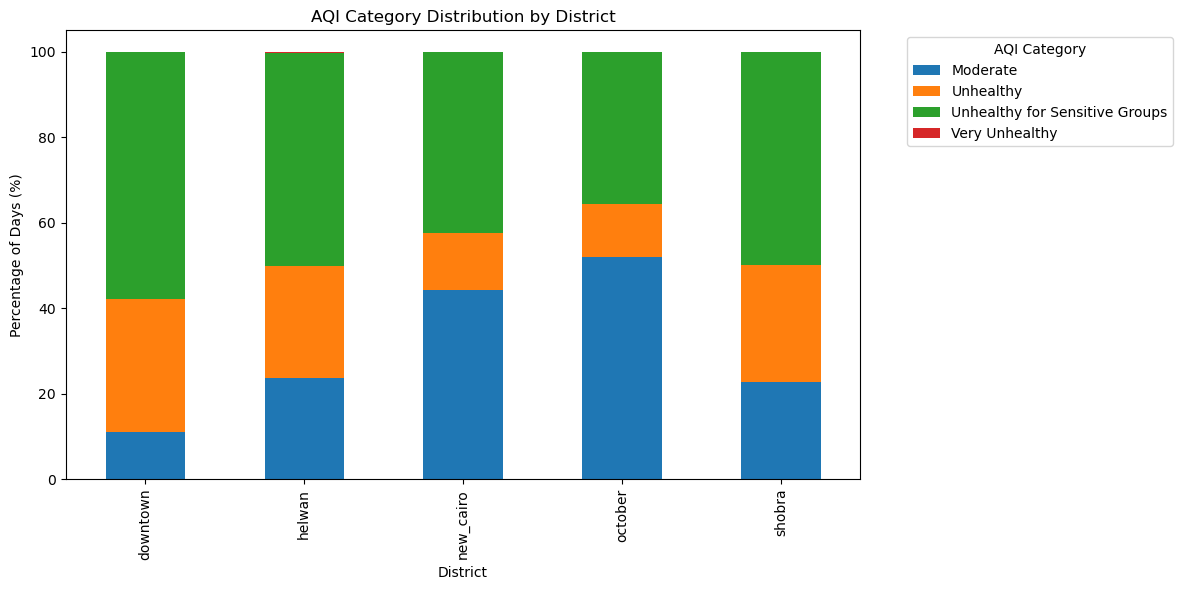

In [24]:
ax = aqi_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

ax.set_xlabel("District")
ax.set_ylabel("Percentage of Days (%)")
ax.set_title("AQI Category Distribution by District")

ax.legend(
    title="AQI Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [15]:
risk_percentages = (
    daily_data.groupby(["station_id", "is_health_risk"])
      .size()
      .groupby(level=0)
      .transform(lambda x: x / x.sum() * 100)
      .unstack(fill_value=0)
)
risk_percentages

is_health_risk,0,1
station_id,,
downtown,68.886861,31.113139
helwan,73.448905,26.551095
new_cairo,86.770073,13.229927
october,87.591241,12.408759
shobra,72.445255,27.554745


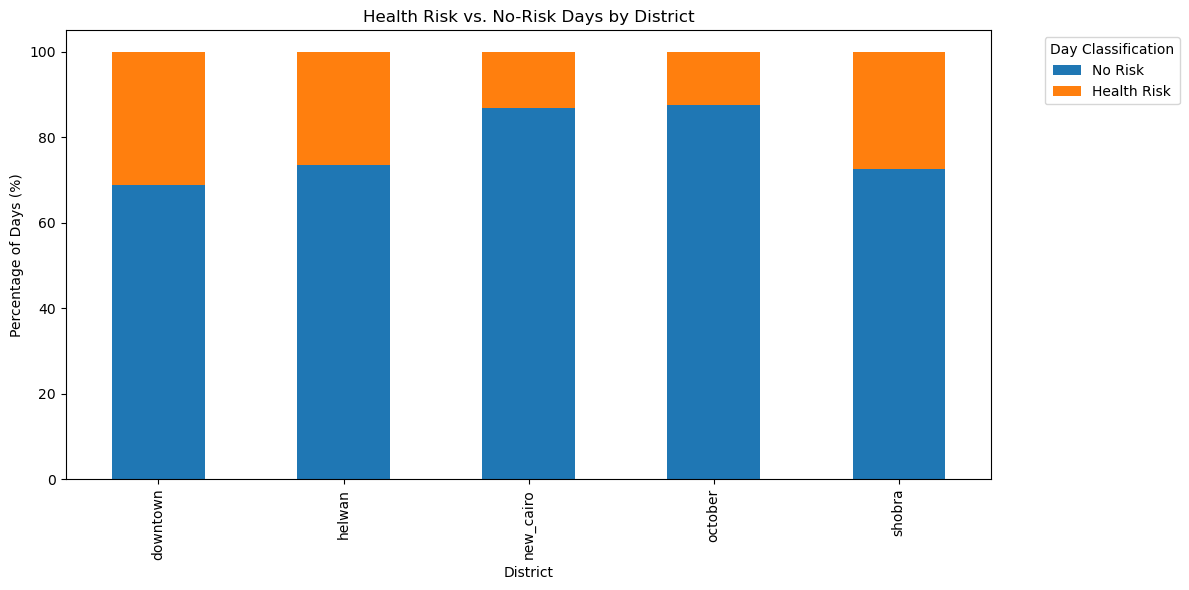

In [23]:
risk_percentages = risk_percentages.rename(columns={
    0: "No Risk",
    1: "Health Risk"
})

ax = risk_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

ax.set_xlabel("District")
ax.set_ylabel("Percentage of Days (%)")
ax.set_title("Health Risk vs. No-Risk Days by District")

ax.legend(
    title="Day Classification",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Wind direction sin/cos encoding

`wind_dir_sin` and `wind_dir_cos` were computed and added to the data

In [53]:
daily_data['wind_direction_10m'].head()

0     11.456289
1    355.349279
2    330.514994
3    282.715789
4    220.323044
Name: wind_direction_10m, dtype: float64

In [54]:
wind_dir_sin = np.sin(daily_data['wind_direction_10m'] * np.pi / 180.0 )
wind_dir_sin.head()

0    0.198620
1   -0.081081
2   -0.492196
3   -0.975474
4   -0.647096
Name: wind_direction_10m, dtype: float64

In [55]:
wind_dir_cos = np.cos(daily_data['wind_direction_10m'] * np.pi / 180.0 )
wind_dir_cos.head()

0    0.980077
1    0.996707
2    0.870485
3    0.220115
4   -0.762408
Name: wind_direction_10m, dtype: float64

In [56]:
daily_data["wind_dir_sin"] = wind_dir_sin
daily_data["wind_dir_cos"] = wind_dir_cos

In [6]:
for column in daily_data.columns:
    print(column)

Unnamed: 0
station_id
day
pm10
uv_index
carbon_monoxide
nitrogen_dioxide
sulphur_dioxide
ozone
s5p_co_col
s5p_no2_col
s5p_o3_col
s5p_so2_col
s5p_co_col_gap_days
s5p_co_col_is_observed
s5p_no2_col_gap_days
s5p_no2_col_is_observed
s5p_o3_col_gap_days
s5p_o3_col_is_observed
s5p_so2_col_gap_days
s5p_so2_col_is_observed
road_length_km_3000
road_density_kmkm2_3000
intersection_count_3000
intersection_density_3000
street_length_avg_3000
circuity_avg_3000
major_road_km_3000
major_road_share_3000
road_length_km_5000
road_density_kmkm2_5000
intersection_count_5000
intersection_density_5000
street_length_avg_5000
circuity_avg_5000
major_road_km_5000
major_road_share_5000
dist_to_major_road_m
industrial_area_km2_3000
industrial_ratio_3000
industrial_count_3000
industrial_area_km2_5000
industrial_ratio_5000
industrial_count_5000
dist_to_industrial_m
pm2_5_corrected
temperature_2m_mean
temperature_2m_max
temperature_2m_min
temperature_2m_std
relative_humidity_2m_mean
relative_humidity_2m_max
relativ

In [ ]:
# Drop all raw angle columns 
daily_data.drop(columns=['wind_direction_10m', 'wind_direction_10m_mean', 'wind_direction_10m_max', 'wind_direction_10m_min',  'wind_direction_10m_std'],inplace= True)

In [26]:
daily_data.to_csv("Merged_cleaned_daily_data.csv")